In [22]:
# ==========================================
# Step 1 : Import Libraries
# ==========================================

import numpy as np
import pickle

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [23]:
import pickle

with open("../models/tokenizer.pkl", "rb") as file:
    tokenizer = pickle.load(file)

print("Tokenizer Loaded Successfully!")

with open("../models/label_encoder.pkl", "rb") as file:
    label_encoder = pickle.load(file)

print("Label Encoder Loaded Successfully!")


import numpy as np

X_train = np.load("../models/X_train.npy")
X_test = np.load("../models/X_test.npy")

y_train = np.load("../models/y_train.npy")
y_test = np.load("../models/y_test.npy")


# Model Parameters
vocab_size = len(tokenizer.word_index) + 1
input_length = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("\nModel Parameters")
print("-" * 30)

print("Vocabulary Size :", vocab_size)
print("Input Length    :", input_length)
print("Intent Classes  :", num_classes)


"""vocab_size = 94 → How many unique words the model knows[(x+1) where x are no of unique words and 1 is reserved for padding].
input_length = 7 → How many word positions each input sentence has after padding.
num_classes = 24 → How many different intent categories the model must choose from."""

Tokenizer Loaded Successfully!
Label Encoder Loaded Successfully!

Model Parameters
------------------------------
Vocabulary Size : 94
Input Length    : 7
Intent Classes  : 24


'vocab_size = 94 → How many unique words the model knows[(x+1) where x are no of unique words and 1 is reserved for padding].\ninput_length = 7 → How many word positions each input sentence has after padding.\nnum_classes = 24 → How many different intent categories the model must choose from.'

In [24]:
"""User Sentences
        │
        ▼
Tokenizer
        │
        ▼
Integer Sequences
        │
        ▼
Padding
        │
        ▼
X_train
        │
        ▼
Embedding Layer
   (Needs vocab_size & input_length)
        │
        ▼
LSTM
        │
        ▼
Dense Layer
   (Needs num_classes)"""

'User Sentences\n        │\n        ▼\nTokenizer\n        │\n        ▼\nInteger Sequences\n        │\n        ▼\nPadding\n        │\n        ▼\nX_train\n        │\n        ▼\nEmbedding Layer\n   (Needs vocab_size & input_length)\n        │\n        ▼\nLSTM\n        │\n        ▼\nDense Layer\n   (Needs num_classes)'

In [25]:
# ==========================================
# Step 3 : Build LSTM Model
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Create model
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=input_length
    )
)

# LSTM Layer
model.add(
    LSTM(128)
)

# Dropout Layer
model.add(
    Dropout(0.5)
)

# Hidden Dense Layer
model.add(
    Dense(64, activation="relu")
)

# Output Layer
model.add(
    Dense(num_classes, activation="softmax")
)

# Display model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
"""Build Model
     │
     ▼
Compile Model
     │
     ├── Optimizer
     ├── Loss Function
     └── Metrics
     │
     ▼
Train Model
why These Choices?

For your weather chatbot:

Parameter	Choice	Reason
Optimizer	Adam()	Fast convergence, excellent default for NLP
Loss	sparse_categorical_crossentropy	Your labels are integer-encoded
Metric	accuracy	Easy way to monitor intent classification performance

Training Pipeline So Far
Preprocessed Data
        │
        ▼
Embedding
        │
        ▼
LSTM
        │
        ▼
Dense
        │
        ▼
Softmax
        │
        ▼
Prediction
        │
        ▼
Loss Function
        │
        ▼
Adam Optimizer
        │
        ▼
Update Weights

"""

'Build Model\n     │\n     ▼\nCompile Model\n     │\n     ├── Optimizer\n     ├── Loss Function\n     └── Metrics\n     │\n     ▼\nTrain Model\nwhy These Choices?\n\nFor your weather chatbot:\n\nParameter\tChoice\tReason\nOptimizer\tAdam()\tFast convergence, excellent default for NLP\nLoss\tsparse_categorical_crossentropy\tYour labels are integer-encoded\nMetric\taccuracy\tEasy way to monitor intent classification performance\n\nTraining Pipeline So Far\nPreprocessed Data\n        │\n        ▼\nEmbedding\n        │\n        ▼\nLSTM\n        │\n        ▼\nDense\n        │\n        ▼\nSoftmax\n        │\n        ▼\nPrediction\n        │\n        ▼\nLoss Function\n        │\n        ▼\nAdam Optimizer\n        │\n        ▼\nUpdate Weights\n\n'

In [27]:
# ==========================================
# Step 4 : Compile the Model
# ==========================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [28]:
# ==========================================
# Step 5 : Train the Model
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0368 - loss: 3.1750 - val_accuracy: 0.0435 - val_loss: 3.1599
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0956 - loss: 3.1436 - val_accuracy: 0.0435 - val_loss: 3.1155
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1029 - loss: 3.0505 - val_accuracy: 0.2029 - val_loss: 2.8915
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2169 - loss: 2.6100 - val_accuracy: 0.2319 - val_loss: 2.1646
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3824 - loss: 1.8752 - val_accuracy: 0.5507 - val_loss: 1.4006
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5919 - loss: 1.2290 - val_accuracy: 0.8986 - val_loss: 0.8830
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.8416 - val_accuracy: 0.8986 - val_loss: 0.5962
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8382 - loss: 0.5739 - val_accuracy: 0.9275 - v

In [29]:
# ==========================================
# Step 6 : Evaluate the Model
# ==========================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n==============================")

print("Test Loss     :", test_loss)

print("Test Accuracy :", test_accuracy)

print("==============================")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9420 - loss: 0.2093

Test Loss     : 0.20926512777805328
Test Accuracy : 0.9420289993286133


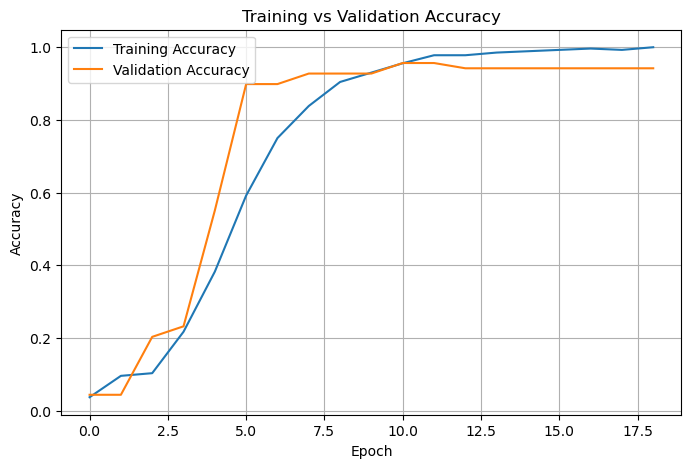

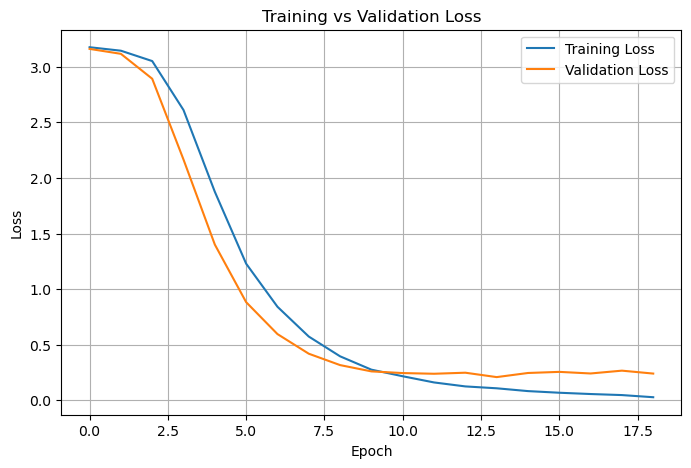

In [30]:
# ==========================================
# Step 7 : Plot Accuracy and Loss Graphs
# ==========================================

import matplotlib.pyplot as plt

# ---------------- Accuracy ----------------

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ---------------- Loss ----------------

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [31]:
# ==========================================
# Step 8 : Save Trained Model
# ==========================================

# Save the trained model
model.save("../models/chatbot.keras")

print("Model saved successfully!")

# Load the model again to verify
from tensorflow.keras.models import load_model

loaded_model = load_model("../models/chatbot.keras")

print("Model loaded successfully!")

# Display summary
loaded_model.summary()

Model saved successfully!
Model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (16, 7, 128)           │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (16, 128)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (16, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (16, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (16, 24)               │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,298 (1.76 MB)

 Trainable params: 153,432 (599.34 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 306,866 (1.17 MB)